In [1]:
import pandas as pd 
import seaborn as sbn
import matplotlib.pyplot as plt 
import umap
import numpy as np

#tsne 
from sklearn.manifold import TSNE

In [2]:
zdf = pd.read_csv('/home/teddy/local/AMLVAE/workflows/runs/mds_fpkm_variance_zscore_2000_latent32/fold_0/eval/mds_z.csv').rename(
    {'Unnamed: 0':'MLL ID'}, axis=1
)
clin = pd.read_excel('/home/teddy/local/data/evansmds/805_data_20250107.xlsx')

df = zdf.merge(clin, on='MLL ID', how='left')

df.head()


,MLL ID,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2
0,MLL_00003,-1.671699,-0.463713,0.209445,0.062639,-1.142147,-0.660748,-0.836006,-0.766731,-1.112834,...,NEGATIVE,NEGATIVE,VARIANT,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
1,MLL_00009,-1.523571,0.733182,-1.141814,0.035658,1.530963,-0.025948,-0.444612,-0.287670,-0.653837,...,NEGATIVE,VARIANT,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
2,MLL_09941,0.730812,-1.699439,1.832329,0.598420,-0.377034,-0.295239,1.556996,-0.179066,0.374362,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
3,MLL_09946,-0.301417,-1.657285,-0.820311,-1.653170,1.731533,-1.459675,0.180960,-0.121000,-0.104331,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
4,MLL_09947,-0.021087,0.034865,0.771965,1.415452,-0.012404,-0.958218,0.087913,-1.782731,1.664006,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,POSITIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE


In [3]:
reducer_method = 'tsne'

if reducer_method == 'umap':
    reducer = umap.UMAP(n_components=2, 
                        metric='cosine', 
                    min_dist=0.5, 
                    n_neighbors=15, 
                    n_epochs=1000,
                    spread=1.)

elif reducer_method == 'tsne':
    reducer = TSNE(n_components=2, perplexity=15, n_iter=5000)

z_columns = [c for c in df.columns if c.startswith('z')]
u = reducer.fit_transform(df.loc[:, z_columns].values.astype(np.float32))

df = df.assign(u1=u[:, 0], u2=u[:, 1]) 


/home/teddy/miniconda3/envs/amlvae/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


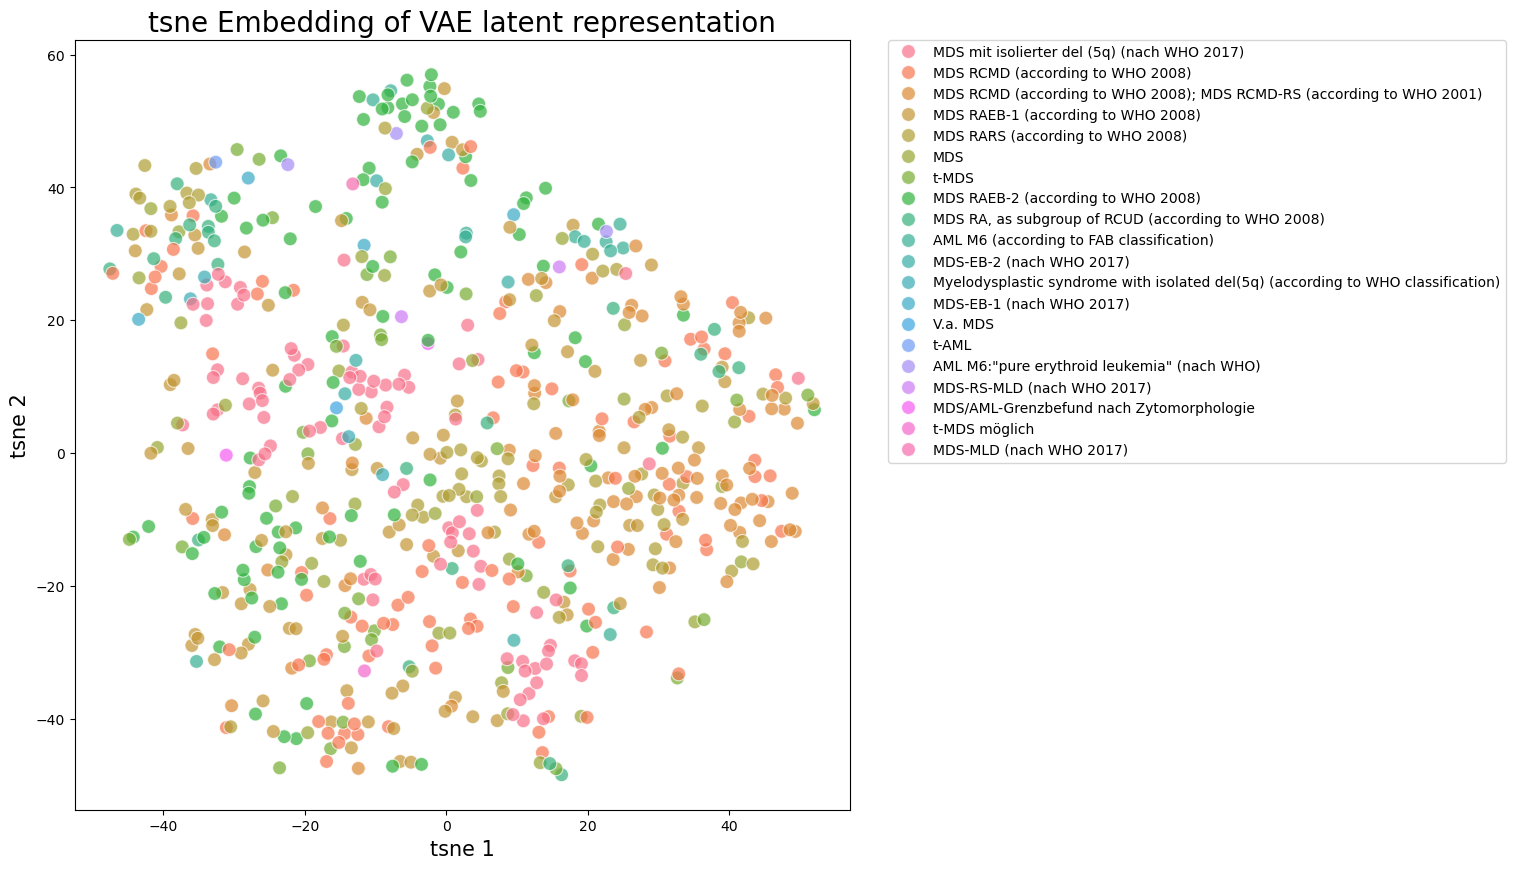

In [4]:
plt.figure(figsize=(10, 10))
sbn.scatterplot(data=df, x='u1', y='u2', hue='Clinical Diagnosis', s=100, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.xlabel(f'{reducer_method} 1', fontsize=15)
plt.ylabel(f'{reducer_method} 2', fontsize=15)
plt.title(f'{reducer_method} Embedding of VAE latent representation', fontsize=20)
plt.show()

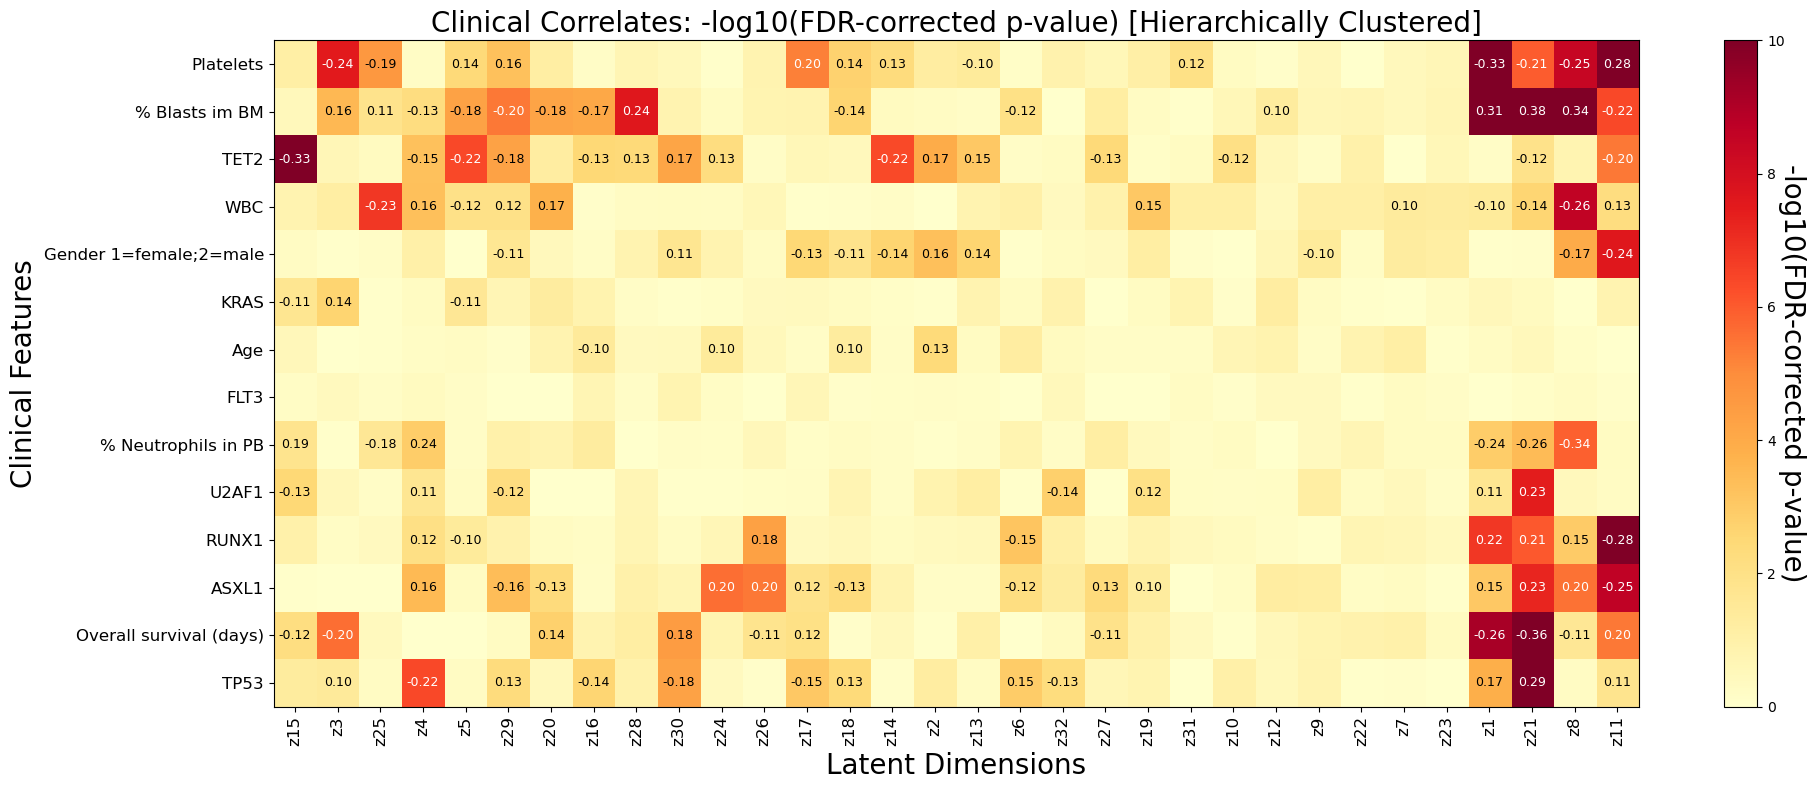


Significant correlations (FDR < 0.05):
Gender 1=female;2=male <-> z2: r=0.155, p=6.19e-05, FDR-p=5.19e-04
Gender 1=female;2=male <-> z8: r=-0.170, p=1.08e-05, FDR-p=1.08e-04
Gender 1=female;2=male <-> z9: r=-0.098, p=1.16e-02, FDR-p=4.20e-02
Gender 1=female;2=male <-> z11: r=-0.236, p=8.10e-10, FDR-p=2.53e-08
Gender 1=female;2=male <-> z13: r=0.138, p=3.70e-04, FDR-p=2.34e-03
Gender 1=female;2=male <-> z14: r=-0.138, p=3.87e-04, FDR-p=2.41e-03
Gender 1=female;2=male <-> z17: r=-0.134, p=5.50e-04, FDR-p=3.24e-03
Gender 1=female;2=male <-> z18: r=-0.114, p=3.47e-03, FDR-p=1.45e-02
Gender 1=female;2=male <-> z29: r=-0.106, p=6.27e-03, FDR-p=2.44e-02
Gender 1=female;2=male <-> z30: r=0.109, p=5.18e-03, FDR-p=2.07e-02
Age <-> z2: r=0.130, p=7.89e-04, FDR-p=4.32e-03
Age <-> z16: r=-0.100, p=1.04e-02, FDR-p=3.90e-02
Age <-> z18: r=0.096, p=1.41e-02, FDR-p=4.92e-02
Age <-> z24: r=0.098, p=1.17e-02, FDR-p=4.20e-02
WBC <-> z1: r=-0.100, p=1.17e-02, FDR-p=4.20e-02
WBC <-> z4: r=0.158, p=6.25e-05

In [ ]:
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# Get z columns (latent dimensions)
z_columns = [c for c in df.columns if c.startswith('z')]

# Specify clinical features of interest
clinical_features = ['Gender 1=female;2=male', 'Age', 'WBC', 'Platelets', '% Blasts im BM', 
                     '% Neutrophils in PB', 'Overall survival (days)', 'U2AF1', 'FLT3', 'RUNX1', 'KRAS', 'ASXL1','TET2', 'TP53']

# Initialize matrices to store correlations and p-values
corr_matrix = np.zeros((len(clinical_features), len(z_columns)))
pval_matrix = np.zeros((len(clinical_features), len(z_columns)))

# Calculate correlations and p-values for each clinical feature vs each latent dimension
for i, clinical_feat in enumerate(clinical_features):
    for j, z_col in enumerate(z_columns):
        # Get non-null values for both columns
        valid_mask = df[[clinical_feat, z_col]].notna().all(axis=1)
        
        if valid_mask.sum() > 3:  # Need at least a few samples for correlation
            x = df.loc[valid_mask, clinical_feat].values
            y = df.loc[valid_mask, z_col].values
            
            # Use Spearman correlation for robustness to outliers
            corr, pval = spearmanr(x, y)
            corr_matrix[i, j] = corr
            pval_matrix[i, j] = pval
        else:
            corr_matrix[i, j] = np.nan
            pval_matrix[i, j] = 1.0

# Apply FDR correction across all tests
pvals_flat = pval_matrix.flatten()
valid_pvals = ~np.isnan(pvals_flat)
pvals_corrected = np.ones_like(pvals_flat)
pvals_corrected[valid_pvals] = multipletests(pvals_flat[valid_pvals], method='fdr_bh')[1]
pval_matrix_corrected = pvals_corrected.reshape(pval_matrix.shape)

# Calculate -log10(p-value) for color mapping (cap at a maximum to avoid infinities)
log_pval_matrix = -np.log10(np.clip(pval_matrix_corrected, 1e-10, 1))

# Create figure with single heatmap
fig, ax = plt.subplots(1, 1, figsize=(20, 8))

# Create custom annotation: show correlation if significant
annot_matrix = np.empty((len(clinical_features), len(z_columns)), dtype=object)
for i in range(len(clinical_features)):
    for j in range(len(z_columns)):
        if pval_matrix_corrected[i, j] < 0.05:
            annot_matrix[i, j] = f'{corr_matrix[i, j]:.2f}'
        else:
            annot_matrix[i, j] = ''

im = ax.imshow(log_pval_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=min(10, log_pval_matrix.max()))
ax.set_xticks(np.arange(len(z_columns)))
ax.set_yticks(np.arange(len(clinical_features)))
ax.set_xticklabels(z_columns, rotation=90, fontsize=12)
ax.set_yticklabels(clinical_features, fontsize=12)
ax.set_xlabel('Latent Dimensions', fontsize=20)
ax.set_ylabel('Clinical Features', fontsize=20)
ax.set_title('Clinical Correlates: -log10(FDR-corrected p-value)', fontsize=20)

# Add text annotations showing correlation coefficients
for i in range(len(clinical_features)):
    for j in range(len(z_columns)):
        text = annot_matrix[i, j]
        if text:
            ax.text(j, i, text, ha='center', va='center', fontsize=9, 
                    color='black' if log_pval_matrix[i, j] < 5 else 'white')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('-log10(FDR-corrected p-value)', rotation=270, labelpad=15, fontsize=20)

plt.tight_layout()
plt.show()

# Print significant correlations
print("\nSignificant correlations (FDR < 0.05):")
print("=" * 80)
for i, clinical_feat in enumerate(clinical_features):
    for j, z_col in enumerate(z_columns):
        if pval_matrix_corrected[i, j] < 0.05:
            print(f"{clinical_feat} <-> {z_col}: r={corr_matrix[i, j]:.3f}, "
                  f"p={pval_matrix[i, j]:.2e}, FDR-p={pval_matrix_corrected[i, j]:.2e}") 

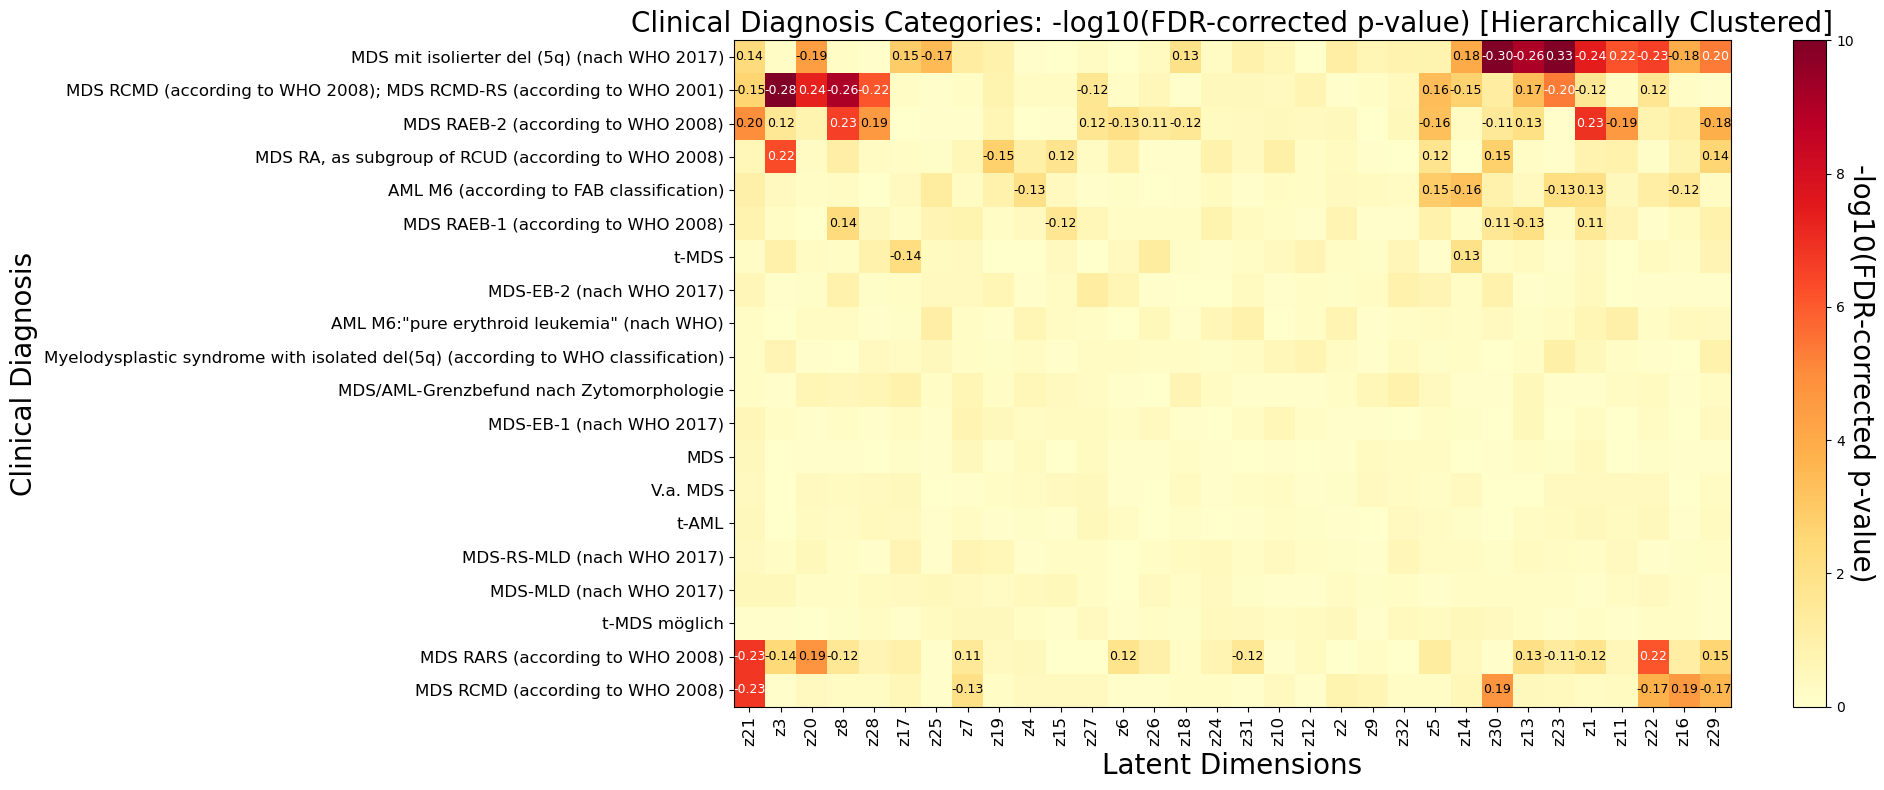


Significant correlations for Clinical Diagnosis categories (FDR < 0.05):
AML M6 (according to FAB classification) (n=14) <-> z1: r=0.130, p=8.04e-04, FDR-p=9.90e-03
AML M6 (according to FAB classification) (n=14) <-> z4: r=-0.129, p=8.74e-04, FDR-p=1.02e-02
AML M6 (according to FAB classification) (n=14) <-> z5: r=0.154, p=7.08e-05, FDR-p=1.26e-03
AML M6 (according to FAB classification) (n=14) <-> z14: r=-0.162, p=3.05e-05, FDR-p=5.58e-04
AML M6 (according to FAB classification) (n=14) <-> z16: r=-0.119, p=2.12e-03, FDR-p=2.17e-02
AML M6 (according to FAB classification) (n=14) <-> z23: r=-0.134, p=5.75e-04, FDR-p=7.67e-03
MDS RA, as subgroup of RCUD (according to WHO 2008) (n=25) <-> z3: r=0.221, p=9.57e-09, FDR-p=4.71e-07
MDS RA, as subgroup of RCUD (according to WHO 2008) (n=25) <-> z5: r=0.123, p=1.53e-03, FDR-p=1.60e-02
MDS RA, as subgroup of RCUD (according to WHO 2008) (n=25) <-> z15: r=0.123, p=1.53e-03, FDR-p=1.60e-02
MDS RA, as subgroup of RCUD (according to WHO 2008) (n=25

In [ ]:
# Heatmap for Clinical Diagnosis categories
# Each diagnosis category is treated as a binary variable

# Get z columns (latent dimensions)
z_columns = [c for c in df.columns if c.startswith('z')]

# Get unique diagnosis categories and filter out NaN
feature = 'Clinical Diagnosis'
diagnosis_categories = df[feature].dropna().unique()
diagnosis_categories = sorted(diagnosis_categories)

# Initialize matrices to store correlations and p-values
corr_matrix_diag = np.zeros((len(diagnosis_categories), len(z_columns)))
pval_matrix_diag = np.zeros((len(diagnosis_categories), len(z_columns)))

# Calculate correlations for each diagnosis category vs each latent dimension
for i, diagnosis in enumerate(diagnosis_categories):
    # Create binary variable: 1 if this diagnosis, 0 otherwise
    binary_var = (df[feature] == diagnosis).astype(int)
    
    for j, z_col in enumerate(z_columns):
        # Get non-null values for the latent dimension
        valid_mask = df[z_col].notna()
        
        if valid_mask.sum() > 3:  # Need at least a few samples for correlation
            x = binary_var[valid_mask].values
            y = df.loc[valid_mask, z_col].values
            
            # Use Spearman correlation
            corr, pval = spearmanr(x, y)
            corr_matrix_diag[i, j] = corr
            pval_matrix_diag[i, j] = pval
        else:
            corr_matrix_diag[i, j] = np.nan
            pval_matrix_diag[i, j] = 1.0

# Apply FDR correction across all tests
pvals_flat_diag = pval_matrix_diag.flatten()
valid_pvals_diag = ~np.isnan(pvals_flat_diag)
pvals_corrected_diag = np.ones_like(pvals_flat_diag)
pvals_corrected_diag[valid_pvals_diag] = multipletests(pvals_flat_diag[valid_pvals_diag], method='fdr_bh')[1]
pval_matrix_corrected_diag = pvals_corrected_diag.reshape(pval_matrix_diag.shape)

# Calculate -log10(p-value) for color mapping
log_pval_matrix_diag = -np.log10(np.clip(pval_matrix_corrected_diag, 1e-10, 1))

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(20, 8))

# Create custom annotation: show correlation if significant
annot_matrix_diag = np.empty((len(diagnosis_categories), len(z_columns)), dtype=object)
for i in range(len(diagnosis_categories)):
    for j in range(len(z_columns)):
        if pval_matrix_corrected_diag[i, j] < 0.05:
            annot_matrix_diag[i, j] = f'{corr_matrix_diag[i, j]:.2f}'
        else:
            annot_matrix_diag[i, j] = ''

im = ax.imshow(log_pval_matrix_diag, cmap='YlOrRd', aspect='auto', vmin=0, vmax=min(10, log_pval_matrix_diag.max()))
ax.set_xticks(np.arange(len(z_columns)))
ax.set_yticks(np.arange(len(diagnosis_categories)))
ax.set_xticklabels(z_columns, rotation=90)
ax.set_yticklabels(diagnosis_categories)
ax.set_xlabel('Latent Dimensions')
ax.set_ylabel(feature)
ax.set_title('Clinical Diagnosis Categories: -log10(FDR-corrected p-value)')

# Add text annotations showing correlation coefficients
for i in range(len(diagnosis_categories)):
    for j in range(len(z_columns)):
        text = annot_matrix_diag[i, j]
        if text:
            ax.text(j, i, text, ha='center', va='center', fontsize=9, 
                    color='black' if log_pval_matrix_diag[i, j] < 5 else 'white')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('-log10(FDR-corrected p-value)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# Print significant correlations
print("\nSignificant correlations for Clinical Diagnosis categories (FDR < 0.05):")
print("=" * 80)
for i, diagnosis in enumerate(diagnosis_categories):
    for j, z_col in enumerate(z_columns):
        if pval_matrix_corrected_diag[i, j] < 0.05:
            # Count how many samples have this diagnosis
            n_with_diagnosis = (df['Clinical Diagnosis'] == diagnosis).sum()
            print(f"{diagnosis} (n={n_with_diagnosis}) <-> {z_col}: r={corr_matrix_diag[i, j]:.3f}, "
                  f"p={pval_matrix_diag[i, j]:.2e}, FDR-p={pval_matrix_corrected_diag[i, j]:.2e}")
